In [1]:
import anndata as ad
from genome_tools.data.anndata import read_zarr_backed
import pandas as pd
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt
import warnings
from tqdm import tqdm
from collections import defaultdict
from genome_tools import GenomicInterval, VariantInterval

In [23]:
#variant file input of all variants
variant_file = '/net/seq/data2/projects/nasi4/ENCODE4/dnase-genotypes.v5/round2/output'
variant_file = '/net/seq/data2/projects/nasi4/ENCODE4/dnase-cavs.v5/output/non_aggregated.extended_annotation.parquet'

In [24]:
variants = pd.read_parquet(variant_file)

In [25]:
# variants

In [26]:
#get individ for mapping to sample_id
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id')
variants["indiv_id"] = (
    variants["sample_id"].map(indiv_id_mapping["indiv_id"]).fillna("").astype(str)
)

In [27]:
#add total counts
variants["total_counts"] = variants.ref_counts + variants.alt_counts


In [28]:
#read count threshold for training data
passed_read_count = (variants.total_counts > 20) & (variants.ref_counts > 0) & (variants.alt_counts > 0)

In [29]:
variants_filtered = variants.loc[passed_read_count].copy()

In [30]:
variants_filtered.shape

(16417578, 42)

In [31]:
#remove duplicate rows
key_cols = ["#chr", "start", "end","ref", "alt", "indiv_id","sample_id"]

variants_no_duplicate = variants_filtered.drop_duplicates(subset=key_cols, keep=False)

In [32]:
#remove places where individual ID has more than one variant at one position with different ref/alt allele
key_cols = ["#chr", "start", "end", "indiv_id"]

# Count unique allele combinations per individual per position
allele_counts = (
    variants_no_duplicate
    .groupby(key_cols)[["ref", "alt"]]
    .nunique()
)

# positions where ref or alt varies (multi-allelic)
multi_mask = (allele_counts["ref"] > 1) | (allele_counts["alt"] > 1)

multi_sites = allele_counts[multi_mask].index

# Remove those rows
variants_no_multiple = variants_no_duplicate[
    ~variants_no_duplicate.set_index(key_cols).index.isin(multi_sites)
].reset_index(drop=True)

In [33]:
variants_no_multiple.shape

(16417472, 42)

In [34]:
variants_no_multiple.to_parquet('/home/mbrannon/tmp/4_15_variantsnomulti.parquet')

In [35]:
#remove duplicates from genotype file
gtfile = '/net/seq/data2/projects/nasi4/ENCODE4/dnase-genotypes.v5/round2/output/all_phased.bed.gz'
genotype_df=pd.read_csv(gtfile,sep='\t',compression='gzip')

In [24]:
#remove duplicates
multi = (
    genotype_df
    .groupby(["#chr", "start", "sample"])[["ref", "alt"]]
    .nunique()
)

multi = multi[(multi["ref"] > 1) | (multi["alt"] > 1)]

In [25]:
multi_sites = multi.reset_index()[["#chr", "start", "sample"]]

In [28]:
genotype_df.shape

(114858154, 8)

In [26]:
genotype_clean = genotype_df.merge(
    multi_sites,
    on=["#chr", "start", "sample"],
    how="left",
    indicator=True
)

genotype_clean = genotype_clean[genotype_clean["_merge"] == "left_only"]
genotype_clean = genotype_clean.drop(columns="_merge")

In [27]:
genotype_clean

,#chr,start,end,ref,alt,sample,genotype,phase_set
0,chr1,792861,792862,C,G,INDIV_0001,1/1,.
1,chr1,792861,792862,C,G,INDIV_0003,1/1,.
2,chr1,792861,792862,C,G,INDIV_0004,1/1,.
3,chr1,792861,792862,C,G,INDIV_0008,1/1,.
4,chr1,792861,792862,C,G,INDIV_0079,0/1,.
...,...,...,...,...,...,...,...,...
114858149,chrEBV,169328,169329,G,C,INDIV_0115,1/1,.
114858150,chrEBV,169370,169371,T,C,INDIV_0115,1/1,.
114858151,chrEBV,169410,169411,T,C,INDIV_0115,1/1,.
114858152,chrEBV,169432,169433,C,T,INDIV_0115,1/1,.


In [13]:
#save genotype without multiallelic
genotype_clean.to_csv(
    "/home/mbrannon/genotype_no_multiallelic.tsv",
    sep="\t",
    index=False,
)

In [20]:
# genotype_clean=pd.read_csv("/home/mbrannon/genotype_no_multiallelic.tsv.gz",sep='\t',compression='gzip')

In [21]:
genotype_clean.head()

,#chr,start,end,ref,alt,sample,genotype,phase_set
0,chr1,792861,792862,C,G,INDIV_0001,1/1,.
1,chr1,792861,792862,C,G,INDIV_0003,1/1,.
2,chr1,792861,792862,C,G,INDIV_0004,1/1,.
3,chr1,792861,792862,C,G,INDIV_0008,1/1,.
4,chr1,792861,792862,C,G,INDIV_0079,0/1,.


In [ ]:
#need to do this before train
!bgzip /home/mbrannon/genotype_no_multiallelic.tsv
!tabix -s 1 -b 2 -e 3 /home/mbrannon/genotype_no_multiallelic.tsv.gz

In [22]:
#assign variant id
variants_no_multiple['variant_id'] = variants_no_multiple['#chr'] + ":" + variants_no_multiple['end'].astype(str) + ':' + variants_no_multiple['ref'] + ':' + variants_no_multiple['alt']


### Add calculations to variants

In [ ]:
#note may need to recalculate group ids due to new clustering

### Create anndata object from variants file

In [3]:
# used_results = pd.read_parquet('/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet')

In [36]:
used_results=variants_no_multiple

In [37]:
used_results.head()

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,pval_alt,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id,indiv_id,total_counts
0,chr1,804903,804904,rs61770167,C,T,10,17,AG72382,0.00757,...,0.123894,0.247789,0.849317,1,-,1,12.792043,B-cell,INDIV_0120,27
1,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.00757,...,0.844748,0.499560,0.937995,1,-,1,14.564382,B-cell,INDIV_0120,35
2,chr1,811013,811014,rs3925105,G,A,16,7,AG80695,0.22730,...,0.879160,0.462712,1.000000,0,-,0,8.899708,Myoblast,INDIV_0130,23
3,chr1,814809,814810,rs573971885,C,T,17,8,AG92965,0.01019,...,0.850311,0.533413,0.929370,1,-,0,9.020596,B-cell,INDIV_0063,25
4,chr1,816320,816321,rs1292241435,A,G,17,10,AG80304,0.00000,...,0.415345,0.830690,0.973761,1,-,1,6.487607,Basal ganglia,INDIV_0094,27


In [38]:
used_results.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'group_id',
       'indiv_id', 'total_counts'],
      dtype='object')

In [ ]:
clean_geno

In [39]:
#make sure variants are in the genotype file
key_variants = ["#chr", "start", "end", "ref", "alt", "indiv_id"]
key_geno = ["#chr", "start", "end", "ref", "alt", "sample"]

variants_wgt_merge = used_results.merge(
    genotype_clean[key_geno],
    left_on=key_variants,
    right_on=key_geno,
    how="inner"
)

In [40]:
# variants_wgt_merge=pd.read_csv('/home/mbrannon/tmp/vwget.csv')
variants_wgt_merge.shape

(16384123, 43)

In [41]:
variants_wgt_merge.head()

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,min_pval,FDR_sample,hotspots,footprints,peaks,inverse_mse,group_id,indiv_id,total_counts,sample
0,chr1,804903,804904,rs61770167,C,T,10,17,AG72382,0.00757,...,0.247789,0.849317,1,-,1,12.792043,B-cell,INDIV_0120,27,INDIV_0120
1,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.00757,...,0.499560,0.937995,1,-,1,14.564382,B-cell,INDIV_0120,35,INDIV_0120
2,chr1,811013,811014,rs3925105,G,A,16,7,AG80695,0.22730,...,0.462712,1.000000,0,-,0,8.899708,Myoblast,INDIV_0130,23,INDIV_0130
3,chr1,814809,814810,rs573971885,C,T,17,8,AG92965,0.01019,...,0.533413,0.929370,1,-,0,9.020596,B-cell,INDIV_0063,25,INDIV_0063
4,chr1,816320,816321,rs1292241435,A,G,17,10,AG80304,0.00000,...,0.830690,0.973761,1,-,1,6.487607,Basal ganglia,INDIV_0094,27,INDIV_0094


In [42]:
used_results = variants_wgt_merge

In [43]:
used_results.to_parquet('/home/mbrannon/tmp/4_15_variants_withcalc_passedgeno.parquet')

In [47]:
used_results.columns

Index(['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'ref_counts', 'alt_counts',
       'sample_id', 'AAF', 'RAF', 'FMR', '#chr.1', 'start.1', 'end.1', 'BAD',
       'SNP_count', 'SNP_ID_count', 'sum_cover', 'Q1.00', 'Q1.50', 'Q2.00',
       'Q2.50', 'Q3.00', 'Q4.00', 'Q5.00', 'Q6.00', 'coverage', 'w', 'es',
       'logit_es', 'pval_ref', 'pval_alt', 'min_pval', 'FDR_sample',
       'hotspots', 'footprints', 'peaks', 'inverse_mse', 'group_id',
       'indiv_id', 'total_counts', 'sample'],
      dtype='object')

In [48]:
import numpy as np

# Numeric columns
layer_cols_numeric = [
    'ref_counts', 'alt_counts',  'BAD',
    'logit_es',  'FDR_sample', 'inverse_mse',
    'total_counts'
]

# Convert numeric columns to float
used_results[layer_cols_numeric] = used_results[layer_cols_numeric].astype(float)


In [49]:
from genome_tools.data.anndata import read_zarr_backed
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')

/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/home/mbrannon/.local/miniconda3/envs/pytorch_clone/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings

In [50]:
used_results['variant_id'] = used_results['#chr'] + ":" + used_results['end'].astype(str) + ':' + used_results['ref'] + ':' + used_results['alt']

In [51]:
used_results['variant_id']

0              chr1:804904:C:T
1              chr1:804904:C:T
2              chr1:811014:G:A
3              chr1:814810:C:T
4              chr1:816321:A:G
                   ...        
16384118    chr9:138217446:C:T
16384119    chr9:138217446:C:T
16384120    chr9:138217446:C:T
16384121    chr9:138219529:T:A
16384122    chr9:138219529:T:A
Name: variant_id, Length: 16384123, dtype: object

In [52]:
var_df = used_results.drop_duplicates('variant_id').set_index('variant_id')[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]

In [53]:
var_df.shape

(1428007, 8)

In [55]:
1343910-1428007

-84097

In [54]:
train_var_adata = ad.AnnData(X=None, var=var_df, obs=adata.obs)
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 1428007
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [56]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 1428007
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [57]:
#rows from variant dataframe (sample id) will be in the obs of anndata
row_idx = used_results['sample_id'].map(lambda x: train_var_adata.obs.index.get_loc(x))
#columns from varaint data frame will be each variant id (chr:start:ref:alt) becomes var
col_idx = used_results['variant_id'].map(lambda x: train_var_adata.var.index.get_loc(x))

In [58]:
for col in layer_cols_numeric:
    data = sp.coo_matrix(
        (used_results[col].values, (row_idx, col_idx)),
        shape=train_var_adata.shape
    ).tocsr()
    train_var_adata.layers[col] = data

In [59]:
train_var_adata.obsm['indiv_id'] = train_var_adata.obs_names.map(indiv_id_mapping['indiv_id']).fillna('').to_numpy().astype(str)

In [60]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 1428007
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [61]:
sampled_val = pd.Series(train_var_adata.obs_names).sample(50).values
validation_chroms = ['chr9', 'chr22']

In [62]:
train_var_adata.obsm['motif_embeddings'] = adata.obsm['motif_embeddings'].loc[train_var_adata.obs_names]

In [63]:
train_var_adata.uns['epoch_names'] = ['epoch_1']
train_var_adata.uns['n_epochs'] = 1
train_var_adata.obsm['split_data'] = np.where(train_var_adata.obs_names.isin(sampled_val), 'val', 'train')
train_var_adata.varm['split_data'] = np.where(train_var_adata.var['#chr'].isin(validation_chroms), 'val', 'train')
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 1428007
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [64]:
for layer in list(train_var_adata.layers):
    train_var_adata.layers[f"{layer}.epoch_1"] = train_var_adata.layers[layer]
    del train_var_adata.layers[layer]

In [65]:
train_var_adata

AnnData object with n_obs × n_vars = 4159 × 1428007
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [66]:
train_var_adata.write_h5ad('/net/seq/data2/projects/mbrannon/4_15_variant_train_adata_20cutoff.h5ad')

In [67]:
#take that anndata and split into 3 epochs


SyntaxError: unterminated string literal (detected at line 2) (799461594.py, line 2)

In [68]:
import numpy as np
import scipy.sparse as sp
import anndata as ad
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm

variant_adata = '/net/seq/data2/projects/mbrannon/4_15_variant_train_adata_20cutoff.h5ad'
#adata = ad.read_h5ad(variant_adata)
adata = train_var_adata
n_rows, n_cols = adata.shape
print("Loaded AnnData:", adata.shape)


Loaded AnnData: (4159, 1428007)


In [69]:
import numpy as np
import scipy.sparse as sp
import anndata as ad
from tqdm import tqdm
import gc


# ==================================================
# Build epoch indices (memory-efficient)
# ==================================================
def build_epoch_indices_filtered(adata, epoch, seed=42):
    
    rng = np.random.default_rng(seed)

    # Source layers (always epoch_1)
    layer_logit = adata.layers["logit_es.epoch_1"].tocoo()
    layer_ref   = adata.layers["ref_counts.epoch_1"].tocoo()
    layer_total = adata.layers["total_counts.epoch_1"].tocoo()
    layer_fdr   = adata.layers["FDR_sample.epoch_1"].tocoo()

    # Compute alt counts
    alt_data = layer_total.data - layer_ref.data

    # Read count filter
    passed_read_count = (
        (layer_total.data > 20) &
        (layer_ref.data > 0) &
        (alt_data > 0)
    )

    # Positive / negative definitions
    sig_if = (layer_fdr.data < 0.1) & (np.abs(layer_logit.data) < 6)
    neg_fdr = layer_fdr.data > 0.5

    # --------------------
    # Positives
    # --------------------
    pos_mask = passed_read_count & sig_if
    pos_rows = layer_logit.row[pos_mask]
    pos_cols = layer_logit.col[pos_mask]

    # --------------------
    # Negatives
    # --------------------
    neg_mask = passed_read_count & neg_fdr
    neg_rows = layer_logit.row[neg_mask]
    neg_cols = layer_logit.col[neg_mask]

    n_pos = len(pos_rows)
    n_neg = len(neg_rows)

    print(f"{epoch} initial positives: {n_pos}")
    print(f"{epoch} initial negatives: {n_neg}")

    # --------------------
    # Balance positives/negatives
    # --------------------
    if n_neg < n_pos:
        print("Downsampling positives")
        keep_pos = rng.choice(n_pos, size=n_neg, replace=False)
        pos_rows = pos_rows[keep_pos]
        pos_cols = pos_cols[keep_pos]
        n_pos = n_neg

    else:
        print("Downsampling negatives")
        keep_neg = rng.choice(n_neg, size=n_pos, replace=False)
        neg_rows = neg_rows[keep_neg]
        neg_cols = neg_cols[keep_neg]
        n_neg = n_pos

    keep_rows = np.concatenate([pos_rows, neg_rows])
    keep_cols = np.concatenate([pos_cols, neg_cols])

    print(f"{epoch}: {n_pos} positives, {n_neg} negatives, total {len(keep_rows)}")

    return pos_rows, pos_cols, neg_rows, neg_cols, keep_rows, keep_cols

In [70]:
def build_epoch_anndata_sparse_filtered(
    adata,
    epochs=("epoch_1", "epoch_2", "epoch_3")
):

    # Detect base layer names automatically
    base_layers = sorted(set(k.split(".")[0] for k in adata.layers.keys()))
    print("Detected layers:", base_layers)

    new = ad.AnnData(
        X=None,
        obs=adata.obs.copy(),
        var=adata.var.copy(),
        obsm=adata.obsm,
        varm=adata.varm,
        uns={"epoch_names": list(epochs)},
    )

    epoch_indices = {}

    for i, epoch in enumerate(tqdm(epochs, desc="Epochs")):

        pos_r, pos_c, neg_r, neg_c, keep_r, keep_c = build_epoch_indices_filtered(
            adata,
            epoch,
            seed=100 + i
        )

        epoch_indices[epoch] = {
            "pos": (pos_r, pos_c),
            "neg": (neg_r, neg_c),
            "keep": (keep_r, keep_c)
        }

        # Build layers
        for key in tqdm(base_layers, desc=f"Building {epoch}", leave=False):

            src_layer = adata.layers[f"{key}.epoch_1"].tocsr()

            # Fast sparse extraction
            layer_data = src_layer[keep_r, keep_c].A1

            new.layers[f"{key}.{epoch}"] = sp.csr_matrix(
                (layer_data, (keep_r, keep_c)),
                shape=adata.shape
            )

        gc.collect()

    return new, epoch_indices

In [71]:
# ==================================================
# Build epochs
# ==================================================
epochs = ["epoch_1", "epoch_2", "epoch_3"]
epoch_adata, epoch_indices = build_epoch_anndata_sparse_filtered(adata, epochs=epochs)

Detected layers: ['BAD', 'FDR_sample', 'alt_counts', 'inverse_mse', 'logit_es', 'ref_counts', 'total_counts']


Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

epoch_1 initial positives: 380570
epoch_1 initial negatives: 15205996
Downsampling negatives
epoch_1: 380570 positives, 380570 negatives, total 761140



Epochs:  33%|███▎      | 1/3 [01:05<02:11, 65.83s/it]          

epoch_2 initial positives: 380570
epoch_2 initial negatives: 15205996
Downsampling negatives
epoch_2: 380570 positives, 380570 negatives, total 761140



Epochs:  67%|██████▋   | 2/3 [02:11<01:05, 65.69s/it]          

epoch_3 initial positives: 380570
epoch_3 initial negatives: 15205996
Downsampling negatives
epoch_3: 380570 positives, 380570 negatives, total 761140



Epochs: 100%|██████████| 3/3 [03:17<00:00, 65.71s/it]          


In [72]:
#check spread

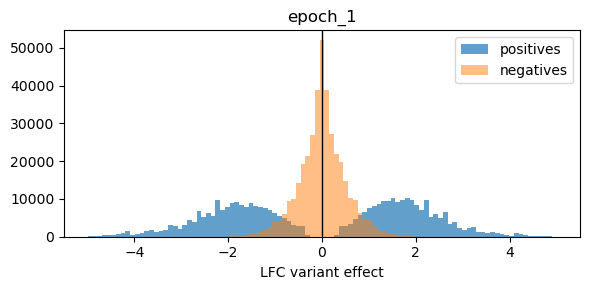

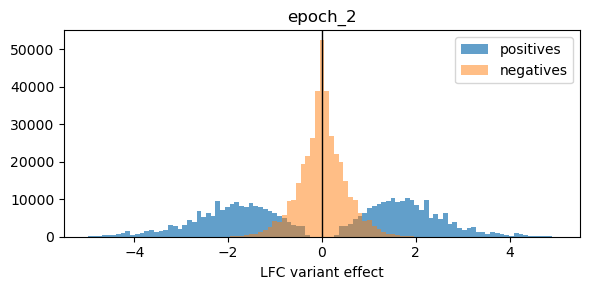

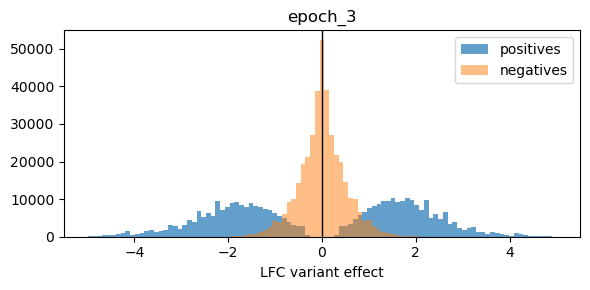

In [73]:
# ==================================================
# Sanity check histograms (match pandas)
# ==================================================
bins = np.linspace(-5, 5, 100)
for epoch, idx_dict in epoch_indices.items():
    logit = epoch_adata.layers[f"logit_es.{epoch}"]

    pos_rows, pos_cols = idx_dict["pos"]
    neg_rows, neg_cols = idx_dict["neg"]

    pos_vals = logit[pos_rows, pos_cols].A1
    neg_vals = logit[neg_rows, neg_cols].A1

    plt.figure(figsize=(6, 3))
    plt.hist(pos_vals, bins=bins, alpha=0.7, label="positives")
    plt.hist(neg_vals, bins=bins, alpha=0.5, label="negatives")
    plt.axvline(0, color="black", lw=1)
    plt.title(epoch)
    plt.xlabel("LFC variant effect")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [74]:
#bounds check
# ==================================================
print("\nRunning sanity checks...")
assert "epoch_names" in epoch_adata.uns
for epoch in epoch_adata.uns["epoch_names"]:
    for base in ["ref_counts", "total_counts", "BAD", "logit_es", "FDR_sample"]:
        layer = f"{base}.{epoch}"
        assert layer in epoch_adata.layers, f"Missing {layer}"
        assert epoch_adata.layers[layer].shape == epoch_adata.shape
print("✔ All epoch layers present")
print("✔ Shapes consistent")
print("✔ Ready for training")


Running sanity checks...
✔ All epoch layers present
✔ Shapes consistent
✔ Ready for training


In [75]:
# Save
out_file = "/net/seq/data2/projects/mbrannon/vinson/4_15_dataset_20totalcount_3epoch.h5ad"
epoch_adata.write_h5ad(out_file, compression="gzip")
print("Saved:", out_file)


Saved: /net/seq/data2/projects/mbrannon/vinson/4_15_dataset_20totalcount_3epoch.h5ad


In [ ]:
#code to train
python submit_to_sbatch.py /net/seq/data2/projects/mbrannon/vinson/3_9_dataset_20totalcount_3epoch.h5ad \
/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
/home/mbrannon/genotype_no_multiallelic.tsv.gz \
/net/seq/data2/projects/mbrannon/variant_model_test \
--config /home/mbrannon/.local/src/vinson/train/variant/legnetMar6.yaml \
--sequence_model_checkpoint /home/mbrannon/.local/src/vinson/train/variant/legnetmar6.ckpt \
--model_type variant \
--env_path /home/mbrannon/.local/miniconda3/envs/pytorch_clone \
--mem 200G  \
--epochs 5 \
--nodelist hpcg04-heavy --debug

In [ ]:
python submit_to_sbatch.py /net/seq/data2/projects/mbrannon/vinson/3_9_dataset_20totalcount1p5bad_3epoch.h5ad \
/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
/home/mbrannon/genotype_no_multiallelic.tsv.gz \
/net/seq/data2/projects/mbrannon/variant_model_test \
--config /home/mbrannon/.local/src/vinson/train/variant/legnetMar6.yaml \
--model_type variant \
--env_path /home/mbrannon/.local/miniconda3/envs/pytorch_clone \
--mem 200G  \
--epochs 100 \
--nodelist hpcg04-heavy 